# Лабораторна робота №4. Розробка Retrieval-Augmented Generation (RAG) системи

**Мета роботи:** ознайомитися з архітектурою RAG, інтегрувати LLM із зовнішнім джерелом даних, оцінити якість відповідей агента та провести аналіз.

**Предметна область:** авіаперевезення та задоволеність пасажирів (продовження теми лабораторних робіт №1–3).
**Корпус документів:** 30 статей англійської Wikipedia про авіакомпанії, класи обслуговування, процес подорожі, права пасажирів і якість сервісу.
**Модель вбудовувань:** BAAI/bge-m3 (бібліотека sentence-transformers, багатомовна, підтримує українські запити до англійських текстів).
**Векторна база:** FAISS (індекс для пошуку за косинусною подібністю).
**Ранжування:** косинусна подібність + повторне ранжування cross-encoder моделлю BAAI/bge-reranker-v2-m3.
**LLM:** Google Gemini (модель сімейства Flash через Gemini API).

**Перед запуском:**
1. «Середовище виконання → Змінити тип середовища виконання» → **T4 GPU**.
2. Ключ Gemini API з https://aistudio.google.com додати в Colab: іконка ключа ліворуч («Secrets») → назва `GEMINI_API_KEY`, увімкнути доступ для ноутбука.

Виконав: Колодійчук Олександр, ст. гр. КНСШ-13

## 1. Встановлення та імпорт бібліотек

In [24]:
# Встановлюємо бібліотеки, яких немає в Colab за замовчуванням:
# google-genai - клієнт Gemini API, faiss-cpu - векторна база,
# sentence-transformers - моделі вбудовувань і повторного ранжування, gradio - простий чат-інтерфейс
!pip install -q google-genai faiss-cpu sentence-transformers gradio

In [25]:
# Стандартні модулі: робота з файлами, JSON, регулярні вирази, час, форматування тексту
import os
import re
import json
import time
import textwrap
# getpass - безпечне введення ключа, якщо його немає в Secrets
from getpass import getpass

# requests - HTTP-запити до Wikipedia API
import requests
# NumPy - робота з векторами та матрицями
import numpy as np
# pandas - таблиці з результатами
import pandas as pd
# matplotlib і seaborn - графіки
import matplotlib.pyplot as plt
import seaborn as sns
# PyTorch - перевірка наявності GPU і половинна точність моделей
import torch
# FAISS - бібліотека векторного пошуку (векторна база)
import faiss
# SentenceTransformer - модель вбудовувань, CrossEncoder - модель повторного ранжування
from sentence_transformers import SentenceTransformer, CrossEncoder
# PCA - зменшення розмірності векторів для візуалізації
from sklearn.decomposition import PCA

# Фіксоване зерно для відтворюваності
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Обчислення на GPU, якщо він доступний (T4 у Colab), інакше на CPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Єдиний стиль графіків і ширина виводу таблиць
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

# Виводимо версії бібліотек і пристрій обчислень
print("PyTorch:", torch.__version__, "| FAISS:", faiss.__version__)
print("Пристрій обчислень:", DEVICE, "-", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "GPU не знайдено")

PyTorch: 2.11.0+cu128 | FAISS: 1.15.1
Пристрій обчислень: cuda - Tesla T4


## 2. Корпус документів: 30 статей Wikipedia

Статті завантажуються через офіційний Wikipedia API у вигляді простого тексту (без HTML-розмітки).
Після першого завантаження корпус зберігається у файл `wiki_corpus.json`, тому повторний запуск не потребує інтернету.

In [26]:
# 30 статей англійської Wikipedia, згрупованих за тематичними категоріями
ARTICLES = {
    "Авіакомпанії та галузь": [
        "Airline", "Low-cost carrier", "Flag carrier", "Airline alliance",
        "Codeshare agreement", "Airline hub", "Air travel"],
    "Класи та сервіс на борту": [
        "First class (aviation)", "Business class", "Premium economy class", "Economy class",
        "Airline seat", "In-flight entertainment", "Airline meal", "Flight attendant"],
    "Процес подорожі": [
        "Airline ticket", "Airport check-in", "Boarding (transport)", "Baggage allowance",
        "Airport security", "Airport lounge", "Jet lag"],
    "Затримки та права пасажирів": [
        "Flight cancellation and delay", "Air Passengers Rights Regulation"],
    "Лояльність і задоволеність": [
        "Frequent-flyer program", "Customer loyalty", "Customer satisfaction",
        "Service quality", "Net promoter score", "Skytrax"],
}

# Адреса Wikipedia API
WIKI_API = "https://en.wikipedia.org/w/api.php"
# Заголовок User-Agent: правила Wikimedia вимагають назву програми і контакт (посилання або e-mail),
# інакше запити з хмарних серверів (Colab) можуть блокуватися помилкою 429
HEADERS = {"User-Agent": "RAG-Lab4/1.0 (https://github.com/Oleksandr-Kolodiichuk; student project) python-requests",
           "Accept-Encoding": "gzip"}
# Файл, у який зберігаємо завантажений корпус
CORPUS_PATH = "wiki_corpus.json"


# Функція завантажує одну статтю Wikipedia у вигляді простого тексту
# (з повторними спробами, якщо сервер тимчасово обмежує кількість запитів)
def fetch_article(title, max_attempts=6):
    # Параметри запиту: extracts - текст статті, explaintext - без HTML, redirects - слідувати перенаправленням
    params = {"action": "query", "format": "json", "prop": "extracts|info", "explaintext": 1,
              "redirects": 1, "inprop": "url", "titles": title, "maxlag": 5}
    for attempt in range(1, max_attempts + 1):
        # Надсилаємо запит
        response = requests.get(WIKI_API, params=params, headers=HEADERS, timeout=30)
        # 429 - забагато запитів, 503 - сервер перевантажений: чекаємо і пробуємо ще раз
        if response.status_code in (429, 503):
            # Сервер може сам підказати час очікування в заголовку Retry-After
            delay = int(response.headers.get("Retry-After", 0) or 0) or 5 * 2 ** (attempt - 1)
            print(f"  {title}: код {response.status_code}, повтор через {delay} с (спроба {attempt}/{max_attempts})")
            time.sleep(delay)
            continue
        # Інші помилки HTTP зупиняють виконання
        response.raise_for_status()
        data = response.json()
        # Wikipedia може попросити зачекати через навантаження (maxlag)
        if "error" in data:
            print(f"  {title}: {data['error'].get('code')}, повтор через 5 с")
            time.sleep(5)
            continue
        # Відповідь містить словник сторінок; беремо єдину сторінку
        page = next(iter(data["query"]["pages"].values()))
        # Якщо статтю не знайдено, повертаємо None
        if "missing" in page:
            return None
        # Повертаємо назву, адресу і текст статті
        return {"title": page["title"], "url": page.get("fullurl", ""), "text": page.get("extract", "")}
    raise RuntimeError(f"Не вдалося завантажити статтю {title}: сервер Wikipedia обмежує запити")


# Якщо корпус уже збережено, завантажуємо його з файлу
if os.path.exists(CORPUS_PATH):
    with open(CORPUS_PATH, encoding="utf-8") as f:
        raw_docs = json.load(f)
    print(f"Корпус завантажено з файлу {CORPUS_PATH}")
# Інакше завантажуємо статті з Wikipedia
else:
    raw_docs = []
    # Проходимо по категоріях і статтях
    for category, titles in ARTICLES.items():
        for title in titles:
            # Завантажуємо статтю
            doc = fetch_article(title)
            # Статтю, якої немає, пропускаємо з повідомленням
            if doc is None or not doc["text"]:
                print(f"  Не знайдено: {title}")
                continue
            # Запам'ятовуємо категорію статті
            doc["category"] = category
            raw_docs.append(doc)
            print(f"  Завантажено: {doc['title']} ({len(doc['text'].split())} слів)")
            # Пауза між статтями, щоб не перевантажувати сервер Wikipedia
            time.sleep(1.5)
    # Зберігаємо корпус у файл
    with open(CORPUS_PATH, "w", encoding="utf-8") as f:
        json.dump(raw_docs, f, ensure_ascii=False)
    print(f"Корпус завантажено з Wikipedia і збережено у {CORPUS_PATH}")

# Таблиця з характеристиками статей
corpus_df = pd.DataFrame([{"Категорія": d["category"], "Стаття": d["title"],
                           "Слів": len(d["text"].split()), "Символів": len(d["text"]),
                           "URL": d["url"]} for d in raw_docs])
# Підсумок корпусу
print(f"Статей у корпусі: {len(raw_docs)}, слів: {corpus_df['Слів'].sum()}, символів: {corpus_df['Символів'].sum()}")
corpus_df

Корпус завантажено з файлу wiki_corpus.json
Статей у корпусі: 30, слів: 79340, символів: 511011


,Категорія,Стаття,Слів,Символів,URL
0,Авіакомпанії та галузь,Airline,9115,59191,https://en.wikipedia.org/wiki/Airline
1,Авіакомпанії та галузь,Low-cost carrier,4093,26366,https://en.wikipedia.org/wiki/Low-cost_carrier
2,Авіакомпанії та галузь,Flag carrier,603,3852,https://en.wikipedia.org/wiki/Flag_carrier
3,Авіакомпанії та галузь,Airline alliance,1238,8428,https://en.wikipedia.org/wiki/Airline_alliance
4,Авіакомпанії та галузь,Codeshare agreement,990,6431,https://en.wikipedia.org/wiki/Codeshare_agreement
5,Авіакомпанії та галузь,Airline hub,2091,13283,https://en.wikipedia.org/wiki/Airline_hub
6,Авіакомпанії та галузь,Air travel,783,5041,https://en.wikipedia.org/wiki/Air_travel
7,Класи та сервіс на борту,First class (aviation),2698,17183,https://en.wikipedia.org/wiki/First_class_(aviation)
8,Класи та сервіс на борту,Business class,2693,17178,https://en.wikipedia.org/wiki/Business_class
9,Класи та сервіс на борту,Premium economy class,2597,16643,https://en.wikipedia.org/wiki/Premium_economy_class


## 3. Попередня обробка: очищення тексту

Очищення прибирає шум, який не несе змісту для пошуку: службові розділи в кінці статей
(References, See also, External links тощо), розмітку заголовків `== ... ==`, посилання-виноски `[1]`,
залишки формул, зайві пробіли та порожні рядки.

In [27]:
# Службові розділи, з яких починається «хвіст» статті без корисного змісту
STOP_SECTIONS = {"see also", "references", "notes", "external links", "further reading",
                 "bibliography", "sources", "citations", "footnotes", "notes and references",
                 "works cited", "general references"}


# Функція очищає текст статті від шуму
def clean_text(text):
    cleaned_lines = []
    # Обробляємо текст по рядках
    for line in text.split("\n"):
        line = line.strip()
        # Перевіряємо, чи рядок є заголовком розділу виду "== History =="
        heading = re.match(r"^(=+)\s*(.*?)\s*\1$", line)
        if heading:
            name = heading.group(2).strip()
            # Дійшли до службового розділу - решту статті відкидаємо
            if name.lower() in STOP_SECTIONS:
                break
            # Звичайний заголовок залишаємо як коротке речення (він допомагає пошуку)
            cleaned_lines.append(name + ".")
            continue
        # Звичайний рядок тексту залишаємо без змін
        cleaned_lines.append(line)
    text = "\n".join(cleaned_lines)
    # Видаляємо виноски [1], [citation needed] та подібні позначки
    text = re.sub(r"\[(\d+|citation needed|edit|clarification needed)\]", "", text)
    # Видаляємо залишки LaTeX-формул {\displaystyle ...}
    text = re.sub(r"\{\\displaystyle[^}]*\}", "", text)
    # Замінюємо нерозривні пробіли та невидимі символи
    text = text.replace(" ", " ").replace("​", "")
    # Видаляємо порожні дужки, що залишились після видалення вмісту
    text = re.sub(r"\(\s*[,;]?\s*\)", "", text)
    # Схлопуємо послідовності пробілів і порожніх рядків
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n\s*\n+", "\n", text)
    # Повертаємо очищений текст без пробілів на краях
    return text.strip()


# Очищаємо всі статті корпусу
docs = []
for d in raw_docs:
    docs.append({**d, "text": clean_text(d["text"])})

# Кількість слів до і після очищення для кожної статті
corpus_df["Слів після очищення"] = [len(d["text"].split()) for d in docs]
corpus_df["Видалено, %"] = (100 * (1 - corpus_df["Слів після очищення"] / corpus_df["Слів"])).round(1)
# Загальний підсумок очищення
before, after = corpus_df["Слів"].sum(), corpus_df["Слів після очищення"].sum()
print(f"Слів до очищення: {before}, після: {after}, видалено: {100 * (1 - after / before):.1f}%")
corpus_df[["Категорія", "Стаття", "Слів", "Слів після очищення", "Видалено, %"]]

Слів до очищення: 79340, після: 77214, видалено: 2.7%


,Категорія,Стаття,Слів,Слів після очищення,"Видалено, %"
0,Авіакомпанії та галузь,Airline,9115,8930,2.0
1,Авіакомпанії та галузь,Low-cost carrier,4093,3989,2.5
2,Авіакомпанії та галузь,Flag carrier,603,562,6.8
3,Авіакомпанії та галузь,Airline alliance,1238,1169,5.6
4,Авіакомпанії та галузь,Codeshare agreement,990,932,5.9
5,Авіакомпанії та галузь,Airline hub,2091,2041,2.4
6,Авіакомпанії та галузь,Air travel,783,754,3.7
7,Класи та сервіс на борту,First class (aviation),2698,2636,2.3
8,Класи та сервіс на борту,Business class,2693,2613,3.0
9,Класи та сервіс на борту,Premium economy class,2597,2553,1.7


In [28]:
# Приклад очищення на статті про регламент ЄС: кінець статті до і після очищення
example = next(i for i, d in enumerate(raw_docs) if d["title"] == "Air Passengers Rights Regulation")
print("=== ДО ОЧИЩЕННЯ (останні 700 символів) ===")
print(raw_docs[example]["text"][-700:])
print("\n=== ПІСЛЯ ОЧИЩЕННЯ (останні 700 символів) ===")
print(docs[example]["text"][-700:])

=== ДО ОЧИЩЕННЯ (останні 700 символів) ===
quivalent regulation in the United States
Contract of carriage – contract between the airline and passenger


== References ==


== External links ==
Regulation (EC) No 261/2004 of the European Parliament and of the Council of 11 February 2004 establishing common rules on compensation and assistance to passengers in the event of denied boarding and of cancellation or long delay of flights, and repealing Regulation (EEC) No 295/91 (PDF)
Explanatory website published by the European Commission
Guidance produced by National Enforcement Bodies on what European regulators consider 'extraordinary circumstances' means (published 22 July 2013)
Interpretative Guidelines on Regulation (EC) No 261/2004

=== ПІСЛЯ ОЧИЩЕННЯ (останні 700 символів) ===
mprovements, such as reducing legal uncertainty by clarifying the definition of "extraordinary circumstances," enhancing protections for connecting journeys, and improving access to information for consumers d

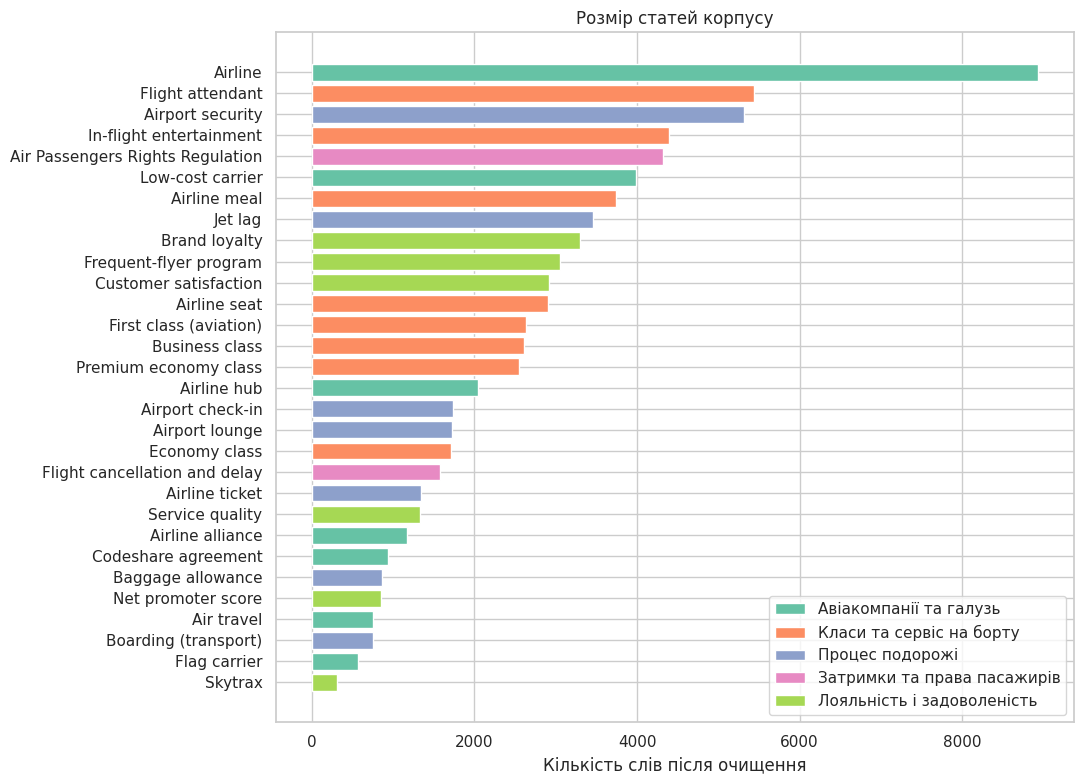

In [29]:
# Графік: кількість слів у кожній статті після очищення, колір - категорія
plot_df = corpus_df.sort_values("Слів після очищення")
fig, ax = plt.subplots(figsize=(11, 8))
# Кольори для п'яти категорій
palette = dict(zip(ARTICLES.keys(), sns.color_palette("Set2", len(ARTICLES))))
ax.barh(plot_df["Стаття"], plot_df["Слів після очищення"], color=plot_df["Категорія"].map(palette))
# Легенда категорій
for cat, color in palette.items():
    ax.bar(0, 0, color=color, label=cat)
ax.legend(loc="lower right")
# Підписи осей і заголовок
ax.set_xlabel("Кількість слів після очищення")
ax.set_title("Розмір статей корпусу")
plt.tight_layout()
plt.show()

## 4. Розбиття на фрагменти (чанки)

Кожна стаття ділиться на фрагменти фіксованої довжини в словах із перекриттям між сусідніми фрагментами.
Перекриття потрібне, щоб думка, розірвана межею фрагмента, повністю потрапила хоча б в один із них.
Основний варіант – **500 слів із перекриттям 100 слів**; для порівняння в розділі 11 також використано фрагменти по 1000 слів.

In [30]:
# Основні параметри розбиття: довжина фрагмента і перекриття (у словах)
CHUNK_SIZE = 500
CHUNK_OVERLAP = 100


# Функція ділить текст на фрагменти по chunk_size слів із перекриттям overlap слів
def split_into_chunks(text, chunk_size, overlap):
    words = text.split()
    # Крок зсуву вікна: наступний фрагмент починається на overlap слів раніше кінця попереднього
    step = chunk_size - overlap
    chunks = []
    for start in range(0, len(words), step):
        # Беремо chunk_size слів, починаючи з позиції start
        chunks.append(" ".join(words[start:start + chunk_size]))
        # Якщо фрагмент дійшов до кінця тексту, зупиняємось
        if start + chunk_size >= len(words):
            break
    return chunks


# Функція формує список фрагментів усього корпусу з метаданими
def make_chunks(documents, chunk_size, overlap):
    all_chunks = []
    for d in documents:
        for i, piece in enumerate(split_into_chunks(d["text"], chunk_size, overlap)):
            all_chunks.append({"chunk_id": len(all_chunks),   # унікальний номер фрагмента
                               "title": d["title"],           # назва статті-джерела
                               "category": d["category"],     # категорія статті
                               "url": d["url"],               # посилання на статтю
                               "chunk_index": i,              # номер фрагмента в статті
                               "n_words": len(piece.split()), # кількість слів
                               "text": piece})                # текст фрагмента
    return all_chunks


# Розбиваємо корпус на фрагменти по 500 слів із перекриттям 100
chunks_500 = make_chunks(docs, CHUNK_SIZE, CHUNK_OVERLAP)
chunks_df = pd.DataFrame(chunks_500)

# Статистика фрагментів
print(f"Фрагментів: {len(chunks_500)} (розмір {CHUNK_SIZE} слів, перекриття {CHUNK_OVERLAP})")
print(f"Слів у фрагменті: мін. {chunks_df['n_words'].min()}, середнє {chunks_df['n_words'].mean():.0f}, макс. {chunks_df['n_words'].max()}")

# Перевірка перекриття: останні 100 слів фрагмента 0 збігаються з першими 100 словами фрагмента 1
same_doc = [c for c in chunks_500 if c["title"] == chunks_500[0]["title"]]
if len(same_doc) > 1:
    tail = same_doc[0]["text"].split()[-CHUNK_OVERLAP:]
    head = same_doc[1]["text"].split()[:CHUNK_OVERLAP]
    print("Перекриття сусідніх фрагментів коректне:", tail == head)

# Приклад фрагмента
print("\nПриклад фрагмента:", chunks_500[0]["title"], "| фрагмент", chunks_500[0]["chunk_index"] + 1)
print(textwrap.fill(chunks_500[0]["text"][:600] + " ...", width=120))

Фрагментів: 204 (розмір 500 слів, перекриття 100)
Слів у фрагменті: мін. 101, середнє 464, макс. 500
Перекриття сусідніх фрагментів коректне: True

Приклад фрагмента: Airline | фрагмент 1
An airline is a company that provides a regular service of air transportation for passengers or freight (cargo).
Airlines use aircraft to supply these services. Many passenger airlines also carry cargo in the belly of their aircraft,
while dedicated cargo airlines focus solely on freight transport. Generally, airlines are recognized with an air
operating certificate or license issued by a governmental aviation body. These airlines may be scheduled or charter
operators. Airline ownership has seen a shift from mostly personal ownership until the 1930s to government-ownership of
major airlines fr ...


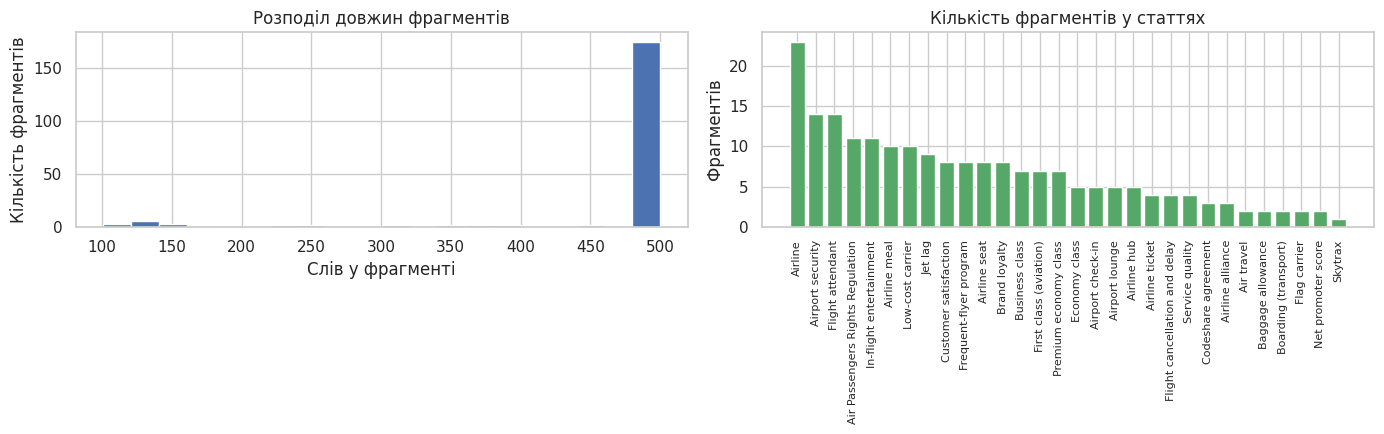

In [31]:
# Графіки: розподіл довжин фрагментів і кількість фрагментів у кожній статті
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
# Гістограма довжин фрагментів (у словах)
axes[0].hist(chunks_df["n_words"], bins=20, color="#4C72B0")
axes[0].set_xlabel("Слів у фрагменті")
axes[0].set_ylabel("Кількість фрагментів")
axes[0].set_title("Розподіл довжин фрагментів")
# Кількість фрагментів у кожній статті
per_doc = chunks_df.groupby("title").size().sort_values(ascending=False)
axes[1].bar(range(len(per_doc)), per_doc.values, color="#55A868")
axes[1].set_xticks(range(len(per_doc)))
axes[1].set_xticklabels(per_doc.index, rotation=90, fontsize=8)
axes[1].set_ylabel("Фрагментів")
axes[1].set_title("Кількість фрагментів у статтях")
plt.tight_layout()
plt.show()

## 5. Модель вбудовувань (embeddings)

Для перетворення тексту у вектори використано бібліотеку **sentence-transformers** і модель **BAAI/bge-m3**:
- багатомовна (понад 100 мов), тому українське питання знаходить англійський текст з тим самим змістом;
- підтримує довгі тексти (до 8192 токенів), тож фрагмент на 500–1000 слів не обрізається;
- вектори розмірності 1024 нормалізуються до одиничної довжини, тому скалярний добуток дорівнює косинусній подібності.

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

/tmp/ipykernel_3553/1208483458.py:20: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  EMBED_DIM = embedder.get_sentence_embedding_dimension()


Модель: BAAI/bge-m3, розмірність вектора: 1024, макс. довжина: 2048 токенів


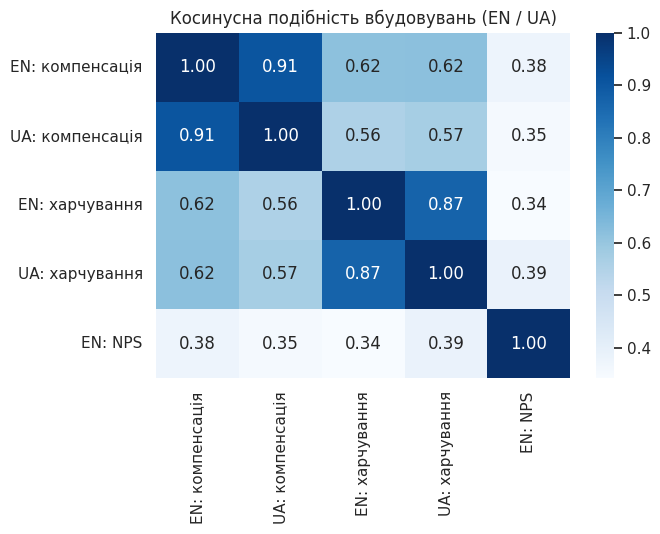

In [32]:
# Назва моделі вбудовувань
EMBED_MODEL_NAME = "BAAI/bge-m3"
# Завантажуємо модель на GPU або CPU
embedder = SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)
# Максимальна довжина входу в токенах: вистачає для фрагментів до 1000 слів
embedder.max_seq_length = 2048
# На GPU переводимо модель у половинну точність для прискорення
if DEVICE == "cuda":
    embedder.half()


# Функція перетворює список текстів у нормалізовані вектори (float32 для FAISS)
def embed(texts, batch_size=16):
    vectors = embedder.encode(texts, batch_size=batch_size, normalize_embeddings=True,
                              convert_to_numpy=True, show_progress_bar=len(texts) > 50)
    return vectors.astype("float32")


# Інформація про модель
EMBED_DIM = embedder.get_sentence_embedding_dimension()
print(f"Модель: {EMBED_MODEL_NAME}, розмірність вектора: {EMBED_DIM}, макс. довжина: {embedder.max_seq_length} токенів")

# Демонстрація: косинусна подібність між англійськими та українськими реченнями
demo_sentences = [
    "Passengers are entitled to compensation when a flight is delayed by more than three hours.",
    "Пасажир має право на компенсацію, якщо рейс затримано більш ніж на три години.",
    "Airline meals are usually served on board during long-haul flights.",
    "На далеких рейсах пасажирам зазвичай подають їжу на борту.",
    "Net promoter score measures how likely customers are to recommend a company.",
]
demo_vectors = embed(demo_sentences)
# Матриця косинусних подібностей: вектори нормалізовані, тому це просто скалярні добутки
similarity = demo_vectors @ demo_vectors.T
# Теплова карта подібностей
labels = ["EN: компенсація", "UA: компенсація", "EN: харчування", "UA: харчування", "EN: NPS"]
plt.figure(figsize=(7, 5.5))
sns.heatmap(similarity, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Косинусна подібність вбудовувань (EN / UA)")
plt.tight_layout()
plt.show()

## 6. Векторна база FAISS: побудова, збереження і завантаження

Векторні представлення всіх фрагментів зберігаються в індексі FAISS `IndexFlatIP` (точний пошук за скалярним добутком).
Оскільки вектори нормалізовані, скалярний добуток дорівнює косинусній подібності.
Індекс, вектори і метадані фрагментів зберігаються на диск і можуть бути завантажені без повторного обчислення.

In [33]:
# Клас векторної бази: індекс FAISS + вектори + метадані фрагментів
class VectorStore:
    # Конструктор: назва бази, порожній індекс і список фрагментів
    def __init__(self, name):
        self.name = name
        self.index = None
        self.chunks = []
        self.embeddings = None

    # Побудова бази: обчислюємо вектори фрагментів і додаємо їх в індекс
    def build(self, chunks):
        self.chunks = chunks
        # До тексту фрагмента додаємо назву статті - це уточнює зміст для моделі вбудовувань
        texts = [f"{c['title']}. {c['text']}" for c in chunks]
        start = time.time()
        self.embeddings = embed(texts)
        # IndexFlatIP - точний пошук за скалярним добутком (= косинусна подібність для нормалізованих векторів)
        self.index = faiss.IndexFlatIP(self.embeddings.shape[1])
        self.index.add(self.embeddings)
        print(f"[{self.name}] векторів у базі: {self.index.ntotal}, розмірність: {self.index.d}, "
              f"час обчислення: {time.time() - start:.1f} с")
        return self

    # Пошук k найближчих векторів до вектора запиту
    def search(self, query_vector, k):
        scores, ids = self.index.search(query_vector.reshape(1, -1), k)
        return scores[0], ids[0]

    # Збереження бази в папку: індекс FAISS, вектори і метадані
    def save(self, folder):
        os.makedirs(folder, exist_ok=True)
        faiss.write_index(self.index, os.path.join(folder, "index.faiss"))
        np.save(os.path.join(folder, "embeddings.npy"), self.embeddings)
        with open(os.path.join(folder, "chunks.json"), "w", encoding="utf-8") as f:
            json.dump(self.chunks, f, ensure_ascii=False)

    # Завантаження бази з папки
    @classmethod
    def load(cls, folder, name):
        store = cls(name)
        store.index = faiss.read_index(os.path.join(folder, "index.faiss"))
        store.embeddings = np.load(os.path.join(folder, "embeddings.npy"))
        with open(os.path.join(folder, "chunks.json"), encoding="utf-8") as f:
            store.chunks = json.load(f)
        return store


# Будуємо основну векторну базу з фрагментів по 500 слів
store_500 = VectorStore("чанки 500").build(chunks_500)
# Зберігаємо базу на диск
store_500.save("vector_db_500")
# Перевірка: завантажуємо базу з диска і порівнюємо з оригіналом
loaded = VectorStore.load("vector_db_500", "чанки 500 (з диска)")
print("Файли бази:", os.listdir("vector_db_500"))
print("Після завантаження векторів:", loaded.index.ntotal, "| вектори збігаються:",
      np.allclose(loaded.embeddings, store_500.embeddings))

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

[чанки 500] векторів у базі: 204, розмірність: 1024, час обчислення: 7.9 с
Файли бази: ['index.faiss', 'embeddings.npy', 'chunks.json']
Після завантаження векторів: 204 | вектори збігаються: True


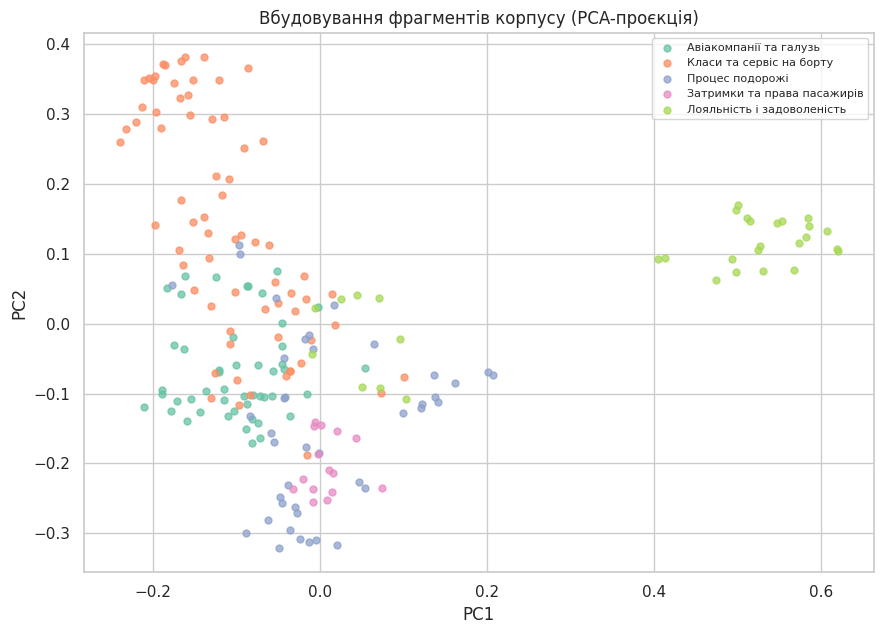

In [34]:
# Візуалізація: проєкція векторів усіх фрагментів на площину методом PCA
points = PCA(n_components=2, random_state=SEED).fit_transform(store_500.embeddings)
fig, ax = plt.subplots(figsize=(9, 6.5))
# Кожна категорія статей - окремим кольором
for cat, color in palette.items():
    mask = np.array([c["category"] == cat for c in store_500.chunks])
    ax.scatter(points[mask, 0], points[mask, 1], s=25, alpha=0.75, color=color, label=cat)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Вбудовування фрагментів корпусу (PCA-проєкція)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Пошук top-k фрагментів і ранжування за релевантністю

Пошук працює у два етапи:
1. **Косинусна подібність:** запит перетворюється у вектор, FAISS повертає фрагменти з найбільшою косинусною подібністю.
2. **Повторне ранжування (reranker, необов'язковий):** cross-encoder BAAI/bge-reranker-v2-m3 оцінює кожну пару «запит – фрагмент» разом
   і дає точнішу оцінку релевантності. Для цього FAISS спочатку повертає ширший список кандидатів (20), а reranker обирає з них top-k.

In [35]:
# Назва моделі повторного ранжування
RERANK_MODEL_NAME = "BAAI/bge-reranker-v2-m3"
# Завантажуємо cross-encoder на GPU або CPU
reranker = CrossEncoder(RERANK_MODEL_NAME, device=DEVICE)
# На GPU - половинна точність для прискорення (у старших версіях бібліотеки - через reranker.model)
if DEVICE == "cuda":
    try:
        reranker.half()
    except AttributeError:
        reranker.model.half()


# Функція пошуку релевантних фрагментів
# query - запит, store - векторна база, top_k - кількість фрагментів у результаті,
# use_reranker - чи застосовувати повторне ранжування, fetch_k - кількість кандидатів для reranker
def retrieve(query, store, top_k=3, use_reranker=False, fetch_k=20):
    # Вектор запиту
    query_vector = embed([query])[0]
    # Етап 1: пошук у FAISS за косинусною подібністю
    scores, ids = store.search(query_vector, fetch_k if use_reranker else top_k)
    results = []
    for score, idx in zip(scores, ids):
        # FAISS повертає -1, якщо векторів менше, ніж k
        if idx < 0:
            continue
        results.append({**store.chunks[idx], "cosine": float(score), "rerank": None})
    # Етап 2: повторне ранжування cross-encoder моделлю
    if use_reranker and results:
        pairs = [(query, f"{r['title']}. {r['text']}") for r in results]
        rerank_scores = reranker.predict(pairs, batch_size=8)
        for r, s in zip(results, rerank_scores):
            r["rerank"] = float(s)
        # Сортуємо за оцінкою reranker
        results.sort(key=lambda r: r["rerank"], reverse=True)
    else:
        # Сортуємо за косинусною подібністю
        results.sort(key=lambda r: r["cosine"], reverse=True)
    # Залишаємо top_k фрагментів і проставляємо ранги
    results = results[:top_k]
    for rank, r in enumerate(results, start=1):
        r["rank"] = rank
    return results


# Функція показує знайдені фрагменти у вигляді таблиці
def sources_table(results):
    return pd.DataFrame([{"Ранг": r["rank"], "Стаття": r["title"], "Фрагмент": r["chunk_index"] + 1,
                          "Косинус": round(r["cosine"], 4),
                          "Reranker": None if r["rerank"] is None else round(r["rerank"], 4),
                          "Початок фрагмента": r["text"][:90] + "..."} for r in results])


print("Reranker завантажено:", RERANK_MODEL_NAME)

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Reranker завантажено: BAAI/bge-reranker-v2-m3


In [36]:
# Демонстрація пошуку: українське питання до англійського корпусу
query = "Яку компенсацію отримує пасажир у ЄС, якщо рейс затримано більш ніж на три години?"
print("Запит:", query)

# Top-5 за косинусною подібністю
print("\nTop-5 за косинусною подібністю (FAISS):")
display(sources_table(retrieve(query, store_500, top_k=5)))

# Top-5 після повторного ранжування cross-encoder моделлю
print("Top-5 після повторного ранжування (reranker):")
display(sources_table(retrieve(query, store_500, top_k=5, use_reranker=True)))

Запит: Яку компенсацію отримує пасажир у ЄС, якщо рейс затримано більш ніж на три години?

Top-5 за косинусною подібністю (FAISS):


,Ранг,Стаття,Фрагмент,Косинус,Reranker,Початок фрагмента
0,1,Air Passengers Rights Regulation,3,0.7307,None,"differentiates between three types of flights: Flights of less than 1,500 km (930 mi) in d..."
1,2,Air Passengers Rights Regulation,1,0.7135,None,The Air Passengers Rights Regulation 2004 (Regulation (EC) No 261/2004) is a regulation in...
2,3,Air Passengers Rights Regulation,10,0.6952,None,"during routine maintenance With respect to compensation for long delays, which was never e..."
3,4,Air Passengers Rights Regulation,4,0.6809,None,"to make payments or otherwise assist passengers, in cases of delays, flight changes/cancel..."
4,5,Air Passengers Rights Regulation,5,0.6682,None,"that intended by the passenger becomes necessary In the case of a delay, the airline may w..."


Top-5 після повторного ранжування (reranker):


,Ранг,Стаття,Фрагмент,Косинус,Reranker,Початок фрагмента
0,1,Air Passengers Rights Regulation,1,0.7135,0.9912,The Air Passengers Rights Regulation 2004 (Regulation (EC) No 261/2004) is a regulation in...
1,2,Flight cancellation and delay,2,0.6262,0.9570,woes following the September 11 attacks. Some of the causes of flight delays or cancellati...
2,3,Air Passengers Rights Regulation,3,0.7307,0.9453,"differentiates between three types of flights: Flights of less than 1,500 km (930 mi) in d..."
3,4,Flight cancellation and delay,1,0.6342,0.8960,A flight delay occurs when an airline flight takes off and/or lands later than its schedul...
4,5,Air Passengers Rights Regulation,6,0.6200,0.8159,prove that the cancellation is caused by extraordinary circumstances which could not have ...


,Стаття,Фрагмент,FAISS (скалярний добуток),Косинус за формулою
0,Air Passengers Rights Regulation,3,0.7307,0.7310
1,Air Passengers Rights Regulation,1,0.7135,0.7138
2,Air Passengers Rights Regulation,10,0.6952,0.6953
3,Air Passengers Rights Regulation,4,0.6809,0.6810
4,Air Passengers Rights Regulation,5,0.6682,0.6685
5,Air Passengers Rights Regulation,8,0.6588,0.6589
6,Air Passengers Rights Regulation,2,0.6475,0.6478
7,Air Passengers Rights Regulation,11,0.6347,0.6349
8,Flight cancellation and delay,1,0.6342,0.6342
9,Air Passengers Rights Regulation,7,0.6302,0.6301


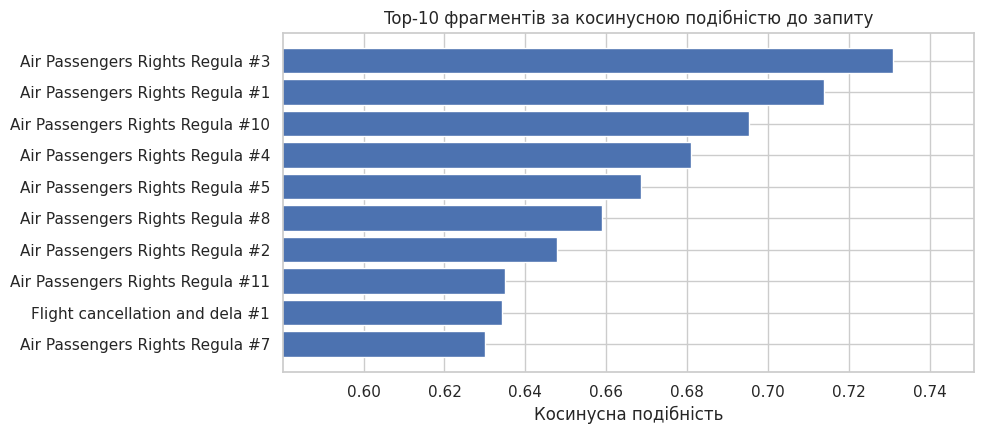

In [37]:
# Перевірка косинусної подібності «вручну»: cos(q, d) = (q · d) / (|q| · |d|)
query_vector = embed([query])[0]
scores, ids = store_500.search(query_vector, 10)
manual = []
for score, idx in zip(scores, ids):
    d = store_500.embeddings[idx]
    cosine = float(np.dot(query_vector, d) / (np.linalg.norm(query_vector) * np.linalg.norm(d)))
    manual.append({"Стаття": store_500.chunks[idx]["title"], "Фрагмент": store_500.chunks[idx]["chunk_index"] + 1,
                   "FAISS (скалярний добуток)": round(float(score), 4), "Косинус за формулою": round(cosine, 4)})
manual_df = pd.DataFrame(manual)
display(manual_df)

# Графік: косинусна подібність top-10 фрагментів до запиту
fig, ax = plt.subplots(figsize=(10, 4.5))
labels = [f"{m['Стаття'][:28]} #{m['Фрагмент']}" for m in manual]
ax.barh(labels[::-1], manual_df["Косинус за формулою"][::-1], color="#4C72B0")
ax.set_xlabel("Косинусна подібність")
ax.set_xlim(manual_df["Косинус за формулою"].min() - 0.05, manual_df["Косинус за формулою"].max() + 0.02)
ax.set_title("Top-10 фрагментів за косинусною подібністю до запиту")
plt.tight_layout()
plt.show()

## 8. Велика мовна модель: Google Gemini

Використано Gemini API (безкоштовний рівень). Модель обирається автоматично: найновіша доступна модель сімейства **Flash**
для генерації відповідей і модель **Flash-Lite** (якщо доступна) для автоматичного оцінювання в розділі 11.
Щоб не перевищувати ліміт запитів за хвилину, між запитами витримується пауза, а при помилці 429 запит автоматично повторюється.

In [38]:
# Клієнт Gemini API і типи конфігурації запитів
from google import genai
from google.genai import types, errors

# Ключ API беремо з Colab Secrets; якщо його там немає - зі змінної середовища або вводимо вручну
try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
except Exception:
    GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY") or getpass("Введіть GEMINI_API_KEY: ")

# Створюємо клієнт Gemini
client = genai.Client(api_key=GEMINI_API_KEY)

# Назви моделей можна задати вручну (наприклад "gemini-2.5-flash"); порожній рядок - автоматичний вибір
LLM_MODEL = ""
JUDGE_MODEL = ""


# Функція повертає список текстових моделей Flash (або Flash-Lite, якщо lite=True), від найкращої до гіршої
def flash_models(lite=False):
    candidates = []
    # Перебираємо всі моделі, доступні для цього ключа
    for m in client.models.list():
        # Коротка назва моделі без префікса "models/"
        name = m.name.split("/")[-1]
        # Дії, які підтримує модель
        actions = m.supported_actions or []
        # Потрібні лише моделі сімейства Flash, що генерують текст
        if "generateContent" not in actions or "flash" not in name:
            continue
        # Пропускаємо спеціалізовані моделі (мовлення, зображення, живий режим, експериментальні)
        if any(x in name for x in ["tts", "live", "image", "audio", "transcribe", "embedding", "exp", "native"]):
            continue
        # Відбираємо Lite або не-Lite моделі
        if ("lite" in name) != lite:
            continue
        candidates.append(name)

    # Порядок переваги: спочатку стабільні версії (без preview), серед них - новіші
    def priority(name):
        version = re.findall(r"gemini-(\d+(?:\.\d+)?)", name)
        return ("preview" not in name, float(version[0]) if version else 0.0)
    return sorted(candidates, key=priority, reverse=True)


# Функція обирає першу модель зі списку, яка реально відповідає на тестовий запит
# (деякі моделі можуть бути недоступні на безкоштовному рівні)
def pick_working_model(lite=False):
    for name in flash_models(lite):
        try:
            client.models.generate_content(model=name, contents="Відповідай одним словом: OK")
            return name
        except errors.APIError as e:
            print(f"  модель {name} недоступна ({e.code}), пробуємо наступну")
            time.sleep(3)
    return None


# Автоматичний вибір моделей, якщо їх не задано вручну
LLM_MODEL = LLM_MODEL or pick_working_model(lite=False)
JUDGE_MODEL = JUDGE_MODEL or pick_working_model(lite=True) or LLM_MODEL
print("Модель для відповідей:", LLM_MODEL)
print("Модель для оцінювання:", JUDGE_MODEL)

Модель для відповідей: gemini-3.8-flash
Модель для оцінювання: gemini-3.5-flash-lite


In [39]:
# Мінімальний інтервал між запитами до API (секунди), щоб не перевищити ліміт запитів за хвилину
MIN_INTERVAL = 6.0
# Час останнього запиту і лічильник запитів
_last_call = 0.0
API_CALLS = 0


# Функція надсилає запит до Gemini з паузою між запитами і повтором при перевищенні ліміту
# contents - текст запиту або список повідомлень діалогу, system - системна інструкція,
# json_mode - вимагати відповідь у форматі JSON
def llm_generate(contents, system=None, model=None, temperature=0.2, json_mode=False):
    global _last_call, API_CALLS
    # Параметри генерації
    config = types.GenerateContentConfig(
        system_instruction=system, temperature=temperature,
        response_mime_type="application/json" if json_mode else None)
    for attempt in range(6):
        # Витримуємо паузу після попереднього запиту
        wait = MIN_INTERVAL - (time.time() - _last_call)
        if wait > 0:
            time.sleep(wait)
        try:
            _last_call = time.time()
            response = client.models.generate_content(model=model or LLM_MODEL, contents=contents, config=config)
            API_CALLS += 1
            return (response.text or "").strip()
        except errors.APIError as e:
            # 429 - перевищено ліміт, 500/503 - тимчасова помилка сервера: чекаємо і повторюємо
            if e.code in (429, 500, 503) and attempt < 5:
                delay = 20 * (attempt + 1)
                print(f"  API {e.code}: повтор через {delay} с")
                time.sleep(delay)
                continue
            raise


# Перевірка роботи моделі простим запитом
print(llm_generate("Одним реченням: що таке RAG (Retrieval-Augmented Generation)?"))

**RAG (Retrieval-Augmented Generation)** — це технологія, яка підвищує точність і актуальність відповідей штучного інтелекту, дозволяючи мовній моделі шукати релевантну інформацію у зовнішніх базах знань безпосередньо перед генерацією тексту.


## 9. RAG-пайплайн

Користувацький запит → пошук релевантних фрагментів → об'єднання контексту → генерація відповіді.
Системна інструкція вимагає від моделі відповідати лише за наданим контекстом і посилатися на номери джерел [1], [2], ...
Якщо відповіді в контексті немає, модель має прямо про це сказати. Так можна перевірити, звідки взято кожне твердження.

In [40]:
# Системна інструкція для RAG: відповідати тільки за контекстом і з посиланнями на джерела
SYSTEM_PROMPT = """Ти – інформаційний асистент з питань авіаперевезень і задоволеності пасажирів.
Відповідай мовою, якою поставлено питання (українською або англійською), лише на основі фрагментів документів із розділу «КОНТЕКСТ».
Правила:
1. Використовуй тільки факти з контексту, нічого не вигадуй і не додавай із власних знань.
2. Після кожного твердження вказуй номер джерела у квадратних дужках, наприклад [1] або [2][3].
3. Якщо в контексті немає відповіді, напиши рівно: «У наданих документах немає інформації для відповіді на це питання.»
   (для питання англійською: «The provided documents contain no information to answer this question.»)
4. Відповідай стисло і логічно: 2–6 речень або короткий список."""

# Системна інструкція для відповіді без RAG (лише знання самої моделі) - для порівняння
NO_RAG_PROMPT = "Ти – інформаційний асистент з питань авіаперевезень. Відповідай мовою питання стисло (2–6 речень)."

# Фрази-відмови (українською та англійською), які модель повертає, якщо відповіді немає в документах
REFUSALS = ["У наданих документах немає інформації", "The provided documents contain no information"]


# Функція об'єднує знайдені фрагменти в один контекст із нумерацією джерел
def build_context(results):
    blocks = []
    for i, r in enumerate(results, start=1):
        blocks.append(f"[{i}] Джерело: {r['title']} (фрагмент {r['chunk_index'] + 1})\n{r['text']}")
    return "\n\n".join(blocks)


# Повний RAG-пайплайн: пошук -> контекст -> генерація
def rag_answer(question, store, top_k=3, use_reranker=False):
    start = time.time()
    # 1. Пошук релевантних фрагментів
    results = retrieve(question, store, top_k=top_k, use_reranker=use_reranker)
    # 2. Об'єднання фрагментів у контекст
    context = build_context(results)
    # 3. Формування запиту до LLM: контекст + питання
    prompt = f"КОНТЕКСТ:\n{context}\n\nПИТАННЯ: {question}\n\nВІДПОВІДЬ:"
    # 4. Генерація відповіді
    answer = llm_generate(prompt, system=SYSTEM_PROMPT)
    return {"question": question, "answer": answer, "sources": results, "context": context,
            "seconds": time.time() - start}


# Відповідь без RAG: питання надсилається моделі без документів
def llm_only_answer(question):
    start = time.time()
    answer = llm_generate(question, system=NO_RAG_PROMPT)
    return {"question": question, "answer": answer, "sources": [], "seconds": time.time() - start}


# Функція гарно виводить результат: питання, джерела, відповідь
def show_result(res, title="RAG"):
    print(f"=== {title} ===")
    print("Питання:", res["question"])
    if res["sources"]:
        display(sources_table(res["sources"]))
    print("Відповідь:")
    print(textwrap.fill(res["answer"], width=120, replace_whitespace=False))
    print(f"(час: {res['seconds']:.1f} с)\n")

In [41]:
# Демонстрація RAG-пайплайну: питання про компенсацію за затримку рейсу (top-3, з reranker)
res = rag_answer("Яку компенсацію отримує пасажир у ЄС, якщо рейс затримано більш ніж на три години?",
                 store_500, top_k=3, use_reranker=True)
show_result(res, "RAG: top-3 + reranker")

# Контекст, який отримала модель (перші 1200 символів)
print("Контекст, переданий моделі (фрагмент):")
print(res["context"][:1200], "...")

=== RAG: top-3 + reranker ===
Питання: Яку компенсацію отримує пасажир у ЄС, якщо рейс затримано більш ніж на три години?


,Ранг,Стаття,Фрагмент,Косинус,Reranker,Початок фрагмента
0,1,Air Passengers Rights Regulation,1,0.7135,0.9912,The Air Passengers Rights Regulation 2004 (Regulation (EC) No 261/2004) is a regulation in...
1,2,Flight cancellation and delay,2,0.6262,0.9570,woes following the September 11 attacks. Some of the causes of flight delays or cancellati...
2,3,Air Passengers Rights Regulation,3,0.7307,0.9453,"differentiates between three types of flights: Flights of less than 1,500 km (930 mi) in d..."


Відповідь:
Якщо затримка рейсу після прибуття становить понад три години (і вона не зумовлена надзвичайними обставинами), пасажир
має право на грошову компенсацію від €250 до €600 залежно від дальності перельоту [1][2][3]:

* **€250** — для рейсів
дальністю менше ніж 1 500 км (тип 1) [3];
* **€400** — для рейсів у межах ЄС понад 1 500 км або будь-яких інших рейсів
від 1 500 до 3 500 км (тип 2) [3];
* **€600** — для рейсів за межами ЄС дальністю понад 3 500 км (тип 3) [3].

Крім
того, перевізник зобов'язаний надати пасажирам прохолодні напої, харчування, засоби зв'язку, а також проживання у
готелі, якщо виліт переноситься на наступний день [1][3].
(час: 8.7 с)

Контекст, переданий моделі (фрагмент):
[1] Джерело: Air Passengers Rights Regulation (фрагмент 1)
The Air Passengers Rights Regulation 2004 (Regulation (EC) No 261/2004) is a regulation in EU law establishing common rules on compensation and assistance to passengers in the event of denied boarding, flight cancellations, or long f

In [42]:
# Порівняння відповіді з RAG і без RAG на конкретному питанні з корпусу
question = "Як розраховується Net Promoter Score і в яких межах він може бути?"
show_result(llm_only_answer(question), "Без RAG (лише LLM)")
show_result(rag_answer(question, store_500, top_k=3, use_reranker=True), "З RAG")

=== Без RAG (лише LLM) ===
Питання: Як розраховується Net Promoter Score і в яких межах він може бути?
Відповідь:
Net Promoter Score (NPS) розраховується на основі відповіді пасажирів на запитання: «Наскільки ймовірно, що ви
порекомендуєте нашу авіакомпанію або аеропорт друзям чи колегам?» за шкалою від 0 до 10. 

Респондентів поділяють на три
категорії: «критики» (0–6 балів), «нейтрали» (7–8 балів) та «промоутери» (9–10 балів). Формула розрахунку проста: від
відсотка промоутерів віднімається відсоток критиків (% Промоутерів – % Критиків), тоді як нейтрали не враховуються.
Показник NPS вимірюється в пунктах і завжди перебуває в межах від **-100** (якщо всі пасажири є критиками) до **+100**
(якщо всі 100% клієнтів є промоутерами).
(час: 8.4 с)

  API 503: повтор через 20 с
  API 503: повтор через 40 с
=== З RAG ===
Питання: Як розраховується Net Promoter Score і в яких межах він може бути?


,Ранг,Стаття,Фрагмент,Косинус,Reranker,Початок фрагмента
0,1,Net promoter score,1,0.6714,0.9932,Net promoter score (NPS) or Customer Net Promoter Score (cNPS) is a market research metric...
1,2,Net promoter score,2,0.5975,0.7222,"service, brand, or company on the basis of respondents' responses to a single survey item...."
2,3,Customer satisfaction,6,0.4596,0.6006,"the national ACSI score is a strong predictor of gross domestic product (GDP) growth, and ..."


Відповідь:
Розрахунок Net Promoter Score полягає у відніманні відсотка «критиків» (detractors, оцінки 6 або нижче) від відсотка
«промоутерів» (promoters, оцінки 9 або 10) [1]. Респонденти з балами 7 або 8 класифікуються як «пасивні» (passives) [1].
Результат обчислення зазвичай подається як ціле число, а не у відсотках [1]. Щодо шкали, у документах зазначено, що цей
показник вимірює готовність рекомендувати компанію за шкалою від 0 до 10 [3], проте точні межі підсумкового
розрахункового балу в контексті не наведені [1][3].
(час: 80.2 с)



In [43]:
# Перевірка на питанні поза корпусом: RAG має відмовитися, а LLM без RAG відповідає з пам'яті
question = "Хто виграв чемпіонат світу з футболу 2018 року?"
show_result(llm_only_answer(question), "Без RAG (лише LLM)")
show_result(rag_answer(question, store_500, top_k=3, use_reranker=True), "З RAG")

=== Без RAG (лише LLM) ===
Питання: Хто виграв чемпіонат світу з футболу 2018 року?
Відповідь:
Чемпіонат світу з футболу 2018 року виграла національна збірна Франції, яка у фіналі перемогла команду Хорватії з
рахунком 4:2. 

Як асистент з авіаперевезень, нагадаю, що моя головна спеціалізація — це консультації щодо перельотів,
рейсів, правил перевезення багажу та роботи аеропортів. Якщо у вас виникнуть запитання щодо планування авіаподорожей, я
залюбки на них відповім!
(час: 3.8 с)

  API 503: повтор через 20 с
  API 503: повтор через 40 с
=== З RAG ===
Питання: Хто виграв чемпіонат світу з футболу 2018 року?


,Ранг,Стаття,Фрагмент,Косинус,Reranker,Початок фрагмента
0,1,Airline hub,3,0.3497,0.0269,"Gulf Air to provide air service. Qatar withdrew its share in Gulf Air in 2002. In 2003, th..."
1,2,In-flight entertainment,9,0.3822,0.0256,Word Traveler that allows passengers to learn a new language in their own language. Appear...
2,3,Flight attendant,7,0.3465,0.0255,"rafts, in-flight firefighting, first aid, CPR, defibrillation, ditching/emergency landing ..."


Відповідь:
У наданих документах немає інформації для відповіді на це питання.
(час: 75.5 с)



In [44]:
# Питання англійською мовою: система працює і з англійськими запитами, відповідь - мовою питання
question = "What is the difference between the piece concept and the weight concept in baggage allowance?"
show_result(rag_answer(question, store_500, top_k=3, use_reranker=True), "RAG: питання англійською")

=== RAG: питання англійською ===
Питання: What is the difference between the piece concept and the weight concept in baggage allowance?


,Ранг,Стаття,Фрагмент,Косинус,Reranker,Початок фрагмента
0,1,Baggage allowance,2,0.7079,0.9814,"of 55 cm (21.6 in) long, 35 cm (13.8 in) wide and 20 cm (7.9 in) deep. If they meet these ..."
1,2,Baggage allowance,1,0.7146,0.9795,"On commercial transportation, mostly with airlines, the baggage allowance is the amount of..."
2,3,Airport check-in,2,0.4731,0.0153,"credit card used for payment. Baggage registration. At the time of check-in, the passenger..."


Відповідь:
Under the Piece Concept, passengers are permitted to check in a specific number of suitcases with an individual weight
limit per bag (typically up to 23 kg for Economy Class and up to 32 kg for Business or First Class) [1]. 

In contrast,
under the Weight Concept, each passenger is allowed a total overall baggage weight regardless of the number of suitcases
checked [1]. Additionally, under the Weight Concept, passengers traveling together are often able to combine their
allowed weights [1]. For both concepts, specific allowances vary by airline, class, elite status, ticket type, origin,
and destination [1].
(час: 6.1 с)



## 10. Історія діалогу

Клас `RAGChat` зберігає історію діалогу. Для уточнювальних питань («А коли вона з'явилася?») модель спершу переписує питання
в самостійну форму з урахуванням історії, і вже за цим формулюванням шукає фрагменти. Під час генерації модель бачить і
контекст, і попередні повідомлення. Історію можна зберегти у файл JSON і завантажити знову.

In [45]:
# Клас чату з пам'яттю діалогу поверх RAG-пайплайну
class RAGChat:
    # Параметри: векторна база, кількість фрагментів, reranker, скільки останніх пар повідомлень пам'ятати
    def __init__(self, store, top_k=4, use_reranker=True, max_turns=5):
        self.store = store
        self.top_k = top_k
        self.use_reranker = use_reranker
        self.max_turns = max_turns
        self.history = []

    # Переписує уточнювальне питання в самостійну форму з урахуванням історії
    def condense(self, question):
        # На першому питанні історії ще немає
        if not self.history:
            return question
        recent = self.history[-2 * self.max_turns:]
        dialog = "\n".join(f"{'Користувач' if h['role'] == 'user' else 'Асистент'}: {h['text']}" for h in recent)
        prompt = (f"Історія діалогу:\n{dialog}\n\nНове питання користувача: {question}\n\n"
                  "Перепиши нове питання так, щоб воно було зрозумілим без історії діалогу "
                  "(заміни займенники та відсилання конкретними назвами). Поверни лише переписане питання.")
        return llm_generate(prompt, temperature=0.0)

    # Відповідь на питання з урахуванням історії
    def ask(self, question):
        start = time.time()
        # 1. Самостійне формулювання питання
        standalone = self.condense(question)
        # 2. Пошук фрагментів за самостійним формулюванням
        results = retrieve(standalone, self.store, top_k=self.top_k, use_reranker=self.use_reranker)
        context = build_context(results)
        # 3. Попередні повідомлення у форматі діалогу Gemini (user / model)
        contents = []
        for h in self.history[-2 * self.max_turns:]:
            role = "user" if h["role"] == "user" else "model"
            contents.append(types.Content(role=role, parts=[types.Part(text=h["text"])]))
        # 4. Нове повідомлення: контекст + питання
        contents.append(types.Content(role="user", parts=[types.Part(
            text=f"КОНТЕКСТ:\n{context}\n\nПИТАННЯ: {question}\n(Самостійне формулювання: {standalone})")]))
        answer = llm_generate(contents, system=SYSTEM_PROMPT)
        # 5. Зберігаємо обидва повідомлення в історію
        self.history.append({"role": "user", "text": question, "standalone": standalone})
        self.history.append({"role": "assistant", "text": answer,
                             "sources": [f"{r['title']} #{r['chunk_index'] + 1}" for r in results]})
        return {"question": question, "standalone": standalone, "answer": answer,
                "sources": results, "seconds": time.time() - start}

    # Збереження історії у файл JSON
    def save(self, path):
        with open(path, "w", encoding="utf-8") as f:
            json.dump(self.history, f, ensure_ascii=False, indent=2)

    # Завантаження історії з файлу JSON
    def load(self, path):
        with open(path, encoding="utf-8") as f:
            self.history = json.load(f)

    # Очищення історії (новий діалог)
    def reset(self):
        self.history = []

In [46]:
# Демонстрація діалогу: друге і третє питання без історії були б незрозумілими
chat = RAGChat(store_500, top_k=4, use_reranker=True)
dialog = ["Що таке програма для частих пасажирів (frequent-flyer program)?",
          "Коли з'явилася перша така програма?",
          "А на що можна витратити накопичені бали?"]
for q in dialog:
    res = chat.ask(q)
    print("Користувач:", q)
    print("Самостійне формулювання:", res["standalone"])
    print("Джерела:", ", ".join(f"[{r['rank']}] {r['title']} #{r['chunk_index'] + 1}" for r in res["sources"]))
    print("Асистент:", textwrap.fill(res["answer"], width=120, replace_whitespace=False))
    print("-" * 120)

# Зберігаємо історію діалогу у файл і перевіряємо завантаження
chat.save("chat_history.json")
restored = RAGChat(store_500)
restored.load("chat_history.json")
print(f"Історію збережено у chat_history.json: {len(restored.history)} повідомлень")

Користувач: Що таке програма для частих пасажирів (frequent-flyer program)?
Самостійне формулювання: Що таке програма для частих пасажирів (frequent-flyer program)?
Джерела: [1] Frequent-flyer program #1, [2] Frequent-flyer program #2, [3] Frequent-flyer program #7, [4] Frequent-flyer program #4
Асистент: Програма для частих пасажирів (frequent-flyer program, FFP) — це програма лояльності, яку пропонує авіакомпанія [1].
Вона створена для заохочення зареєстрованих клієнтів накопичувати бали (також відомі як милі, кілометри або сегменти),
які згодом можна обміняти на авіаперельоти чи інші винагороди [1]. Зароблені бали можуть нараховуватися залежно від
класу тарифу, відстані польоту або витраченої суми [1]. Такі програми можна розглядати як різновид віртуальної валюти з
одностороннім рухом грошей на придбання балів без можливості зворотного обміну на гроші [1].
------------------------------------------------------------------------------------------------------------------------
  API 5

## 11. Оцінка якості роботи системи

**Контрольний набір:** 15 питань – 14 з відповідями в корпусі (з еталонними відповідями і статтями-джерелами) та 1 питання поза корпусом.
Кожне питання подано українською та англійською: якість пошуку порівнюється для обох мов (крос-мовний і одномовний пошук),
а відповіді генеруються й оцінюються для українських питань.

**Параметри, що порівнюються:**
- A – без RAG (лише LLM);
- B – фрагменти по 500 слів, top-3, косинусна подібність;
- C – фрагменти по 500 слів, top-5, косинусна подібність + reranker;
- D – фрагменти по 1000 слів, top-3, косинусна подібність.

**Метрики:**
- якість пошуку: Hit@k (чи є потрібна стаття серед знайдених) і MRR (середній обернений ранг першого правильного джерела);
- якість відповідей: точність, повнота і узгодженість за шкалою 1–5 (оцінює модель-суддя за еталонною відповіддю).

In [47]:
# Контрольний набір питань: питання українською і англійською, еталонна відповідь (ключові факти зі статей) і статті-джерела
EVAL_SET = [
    {"id": 1, "question": "За якої затримки рейсу і яку грошову компенсацію передбачає регламент ЄС № 261/2004?",
     "question_en": "What delay entitles a passenger to compensation under EU Regulation 261/2004, and how much compensation is paid?",
     "reference": "Компенсація належить за затримку понад три години. Сума залежить від відстані: 250 євро для рейсів до 1500 км, 400 євро для рейсів 1500–3500 км, 600 євро для рейсів понад 3500 км.",
     "sources": ["Air Passengers Rights Regulation", "Flight cancellation and delay"]},
    {"id": 2, "question": "Як розраховується Net Promoter Score і в яких межах він може бути?",
     "question_en": "How is the Net Promoter Score calculated and what is its range?",
     "reference": "Клієнти оцінюють готовність рекомендувати компанію за шкалою 0–10: 9–10 – промоутери, 7–8 – пасивні, 0–6 – критики. NPS = частка промоутерів мінус частка критиків (у відсотках); значення від −100 до +100.",
     "sources": ["Net promoter score"]},
    {"id": 3, "question": "Хто і коли запропонував метрику Net Promoter Score?",
     "question_en": "Who introduced the Net Promoter Score and when?",
     "reference": "Фред Райхгельд (Fred Reichheld) з Bain & Company у статті «The One Number You Need to Grow» у Harvard Business Review у грудні 2003 року.",
     "sources": ["Net promoter score"]},
    {"id": 4, "question": "Що таке Skytrax і як вона оцінює авіакомпанії?",
     "question_en": "What is Skytrax and how does it rate airlines?",
     "reference": "Skytrax – британська консалтингова компанія з Лондона, заснована в 1989 році, що веде сайт відгуків про авіакомпанії та аеропорти. Вона присуджує авіакомпаніям від однієї до п'яти зірок і щороку проводить World Airline Awards.",
     "sources": ["Skytrax"]},
    {"id": 5, "question": "Які п'ять вимірів якості послуг виділяє модель SERVQUAL і хто її розробив?",
     "question_en": "What are the five dimensions of service quality in the SERVQUAL model and who developed it?",
     "reference": "Надійність (reliability), впевненість (assurance), матеріальні елементи (tangibles), емпатія (empathy) і чуйність (responsiveness), абревіатура RATER. Модель розробили Парасураман, Зейтамл і Беррі (1985).",
     "sources": ["Service quality"]},
    {"id": 6, "question": "Коли з'явилися перші програми для частих пасажирів?",
     "question_en": "When did the first frequent-flyer programs appear?",
     "reference": "Першу сучасну програму створила Western Direct Marketing для United у 1972 році; Texas International Airlines у 1979 році першою використала облік миль для винагород; програма AAdvantage від American Airlines з'явилася у 1981 році, після неї – програми інших авіакомпаній.",
     "sources": ["Frequent-flyer program"]},
    {"id": 7, "question": "Які найбільші альянси авіакомпаній існують і коли їх засновано?",
     "question_en": "What are the largest airline alliances and when were they founded?",
     "reference": "Три найбільші альянси: Star Alliance (1997), Oneworld (1999) і SkyTeam (2000); найбільший – Star Alliance.",
     "sources": ["Airline alliance"]},
    {"id": 8, "question": "Чому виникає джетлаг, у якому напрямку перельоту він переноситься важче і скільки триває відновлення?",
     "question_en": "Why does jet lag occur, which direction of travel is harder, and how long does recovery take?",
     "reference": "Джетлаг виникає через розбіжність внутрішнього циркадного годинника і місцевого часу після швидкого перетину часових поясів. Важче переноситься переліт на схід. Відновлення триває в середньому приблизно один день на кожну годину різниці в часі.",
     "sources": ["Jet lag"]},
    {"id": 9, "question": "Чим відрізняються Piece Concept і Weight Concept у нормах перевезення багажу?",
     "question_en": "What is the difference between the piece concept and the weight concept in baggage allowance?",
     "reference": "За Piece Concept дозволено певну кількість місць багажу з обмеженням ваги кожного (до 23 кг в економ-класі); за Weight Concept обмежено загальну вагу багажу незалежно від кількості валіз.",
     "sources": ["Baggage allowance"]},
    {"id": 10, "question": "Що таке seat pitch і яким він зазвичай є в економ-класі?",
     "question_en": "What is seat pitch and what is it typically in economy class?",
     "reference": "Seat pitch – відстань між точкою на одному сидінні і тією самою точкою на сидінні попереду. В економ-класі багатьох перевізників вона становить 29–32 дюйми (74–81 см).",
     "sources": ["Airline seat", "Economy class"]},
    {"id": 11, "question": "Які основні риси бізнес-моделі лоукостерів?",
     "question_en": "What are the main features of the low-cost carrier business model?",
     "reference": "Переважно прямі рейси «точка–точка», короткі маршрути, часто до другорядних аеропортів, один клас обслуговування, мінімальний сервіс і додаткова плата за послуги (зокрема багаж), низькі тарифи, висока інтенсивність використання літаків і короткий час обороту, парк з одного-двох типів літаків, онлайн-продаж квитків.",
     "sources": ["Low-cost carrier"]},
    {"id": 12, "question": "Що таке клас преміум-економ і яка авіакомпанія першою його запровадила?",
     "question_en": "What is premium economy class and which airline introduced it first?",
     "reference": "Преміум-економ – клас між економ і бізнес-класом за ціною, комфортом і сервісом, з більшою відстанню між рядами. Першою його запровадила EVA Air 12 грудня 1992 року на рейсі Тайбей – Лос-Анджелес (Economy Deluxe Class).",
     "sources": ["Premium economy class"]},
    {"id": 13, "question": "Що таке код-шерінг і чим операційний перевізник відрізняється від маркетингового?",
     "question_en": "What is a codeshare agreement and how does the operating carrier differ from the marketing carrier?",
     "reference": "Код-шерінг – угода, за якою два або більше перевізників продають той самий рейс під своїми кодами і номерами. Операційний перевізник фактично виконує рейс (має дозволи, слоти, керує рейсом), маркетинговий – продає місця на рейс під своїм кодом, не виконуючи його.",
     "sources": ["Codeshare agreement"]},
    {"id": 14, "question": "Коли зазвичай відкривається онлайн-реєстрація на рейс і яка авіакомпанія першою її запровадила?",
     "question_en": "When does online check-in usually open and which airline introduced it first?",
     "reference": "Онлайн-реєстрація зазвичай відкривається не раніше ніж за 24 години до вильоту; пасажир підтверджує присутність на рейсі через інтернет і друкує посадковий талон. Першою її запровадила Alaska Airlines у 1999 році.",
     "sources": ["Airport check-in"]},
    {"id": 15, "question": "Хто виграв чемпіонат світу з футболу 2018 року?",
     "question_en": "Who won the 2018 FIFA World Cup?",
     "reference": "Питання поза корпусом. Правильна поведінка системи – повідомити, що в наданих документах немає інформації.",
     "sources": []},
]

# Таблиця контрольних питань
eval_df = pd.DataFrame(EVAL_SET)
eval_df["Тип"] = np.where(eval_df["sources"].str.len() > 0, "у корпусі", "поза корпусом")
print(f"Контрольних питань: {len(EVAL_SET)} (у корпусі: {(eval_df['Тип'] == 'у корпусі').sum()}, поза корпусом: {(eval_df['Тип'] == 'поза корпусом').sum()})")
eval_df[["id", "question", "question_en", "sources", "Тип"]]

Контрольних питань: 15 (у корпусі: 14, поза корпусом: 1)


,id,question,question_en,sources,Тип
0,1,За якої затримки рейсу і яку грошову компенсацію передбачає регламент ЄС № 261/2004?,"What delay entitles a passenger to compensation under EU Regulation 261/2004, and how much compensation is paid?","[Air Passengers Rights Regulation, Flight cancellation and delay]",у корпусі
1,2,Як розраховується Net Promoter Score і в яких межах він може бути?,How is the Net Promoter Score calculated and what is its range?,[Net promoter score],у корпусі
2,3,Хто і коли запропонував метрику Net Promoter Score?,Who introduced the Net Promoter Score and when?,[Net promoter score],у корпусі
3,4,Що таке Skytrax і як вона оцінює авіакомпанії?,What is Skytrax and how does it rate airlines?,[Skytrax],у корпусі
4,5,Які п'ять вимірів якості послуг виділяє модель SERVQUAL і хто її розробив?,What are the five dimensions of service quality in the SERVQUAL model and who developed it?,[Service quality],у корпусі
5,6,Коли з'явилися перші програми для частих пасажирів?,When did the first frequent-flyer programs appear?,[Frequent-flyer program],у корпусі
6,7,Які найбільші альянси авіакомпаній існують і коли їх засновано?,What are the largest airline alliances and when were they founded?,[Airline alliance],у корпусі
7,8,"Чому виникає джетлаг, у якому напрямку перельоту він переноситься важче і скільки триває відновлення?","Why does jet lag occur, which direction of travel is harder, and how long does recovery take?",[Jet lag],у корпусі
8,9,Чим відрізняються Piece Concept і Weight Concept у нормах перевезення багажу?,What is the difference between the piece concept and the weight concept in baggage allowance?,[Baggage allowance],у корпусі
9,10,Що таке seat pitch і яким він зазвичай є в економ-класі?,What is seat pitch and what is it typically in economy class?,"[Airline seat, Economy class]",у корпусі


In [48]:
# Друга векторна база для порівняння: фрагменти по 1000 слів із перекриттям 200
chunks_1000 = make_chunks(docs, 1000, 200)
store_1000 = VectorStore("чанки 1000").build(chunks_1000)
store_1000.save("vector_db_1000")
# Словник баз для експериментів
STORES = {"500": store_500, "1000": store_1000}

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

[чанки 1000] векторів у базі: 103, розмірність: 1024, час обчислення: 8.8 с


Hit@1  Hit@3  Hit@5  MRR@10
Варіант пошуку               Мова питань                             
500 слів, косинус            UA           1.000  1.000  1.000   1.000
                             EN           1.000  1.000  1.000   1.000
500 слів, косинус + reranker UA           0.857  0.929  0.929   0.902
                             EN           0.929  1.000  1.000   0.964
1000 слів, косинус           UA           1.000  1.000  1.000   1.000
                             EN           1.000  1.000  1.000   1.000

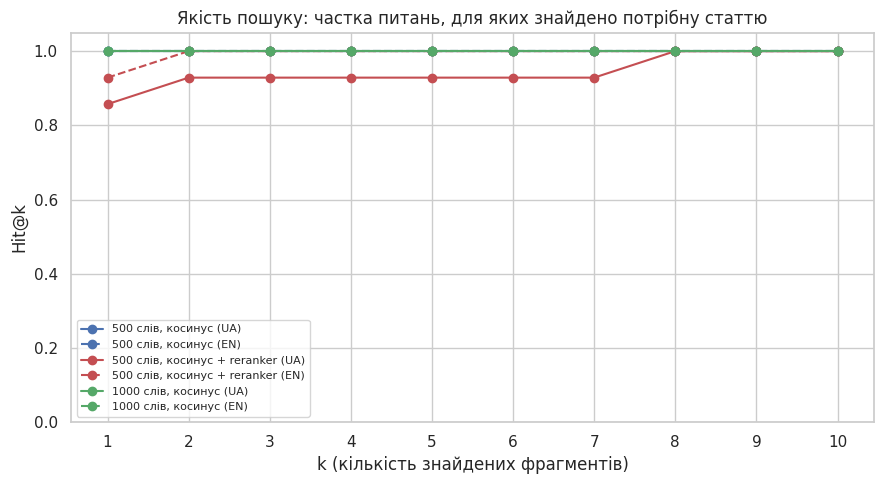

In [49]:
# ===== Оцінка якості пошуку (без звернень до LLM) =====
# Варіанти пошуку, які порівнюємо
SEARCH_VARIANTS = {"500 слів, косинус": ("500", False),
                   "500 слів, косинус + reranker": ("500", True),
                   "1000 слів, косинус": ("1000", False)}
MAX_K = 10
# Питання, відповідь на які є в корпусі
in_corpus = [q for q in EVAL_SET if q["sources"]]

# Мови питань: українська (крос-мовний пошук) і англійська (одномовний пошук)
LANGS = {"UA": "question", "EN": "question_en"}

# Для кожного варіанту, мови і питання визначаємо позицію першого фрагмента з потрібної статті
positions = {}
for variant, (store_key, use_rr) in SEARCH_VARIANTS.items():
    for lang, field in LANGS.items():
        positions[(variant, lang)] = []
        for q in in_corpus:
            # Шукаємо MAX_K фрагментів
            found = retrieve(q[field], STORES[store_key], top_k=MAX_K, use_reranker=use_rr)
            titles = [r["title"] for r in found]
            # Позиція першого фрагмента з потрібної статті (None, якщо не знайдено)
            pos = next((i + 1 for i, t in enumerate(titles) if t in q["sources"]), None)
            positions[(variant, lang)].append(pos)

# Hit@k - частка питань, для яких потрібна стаття є серед перших k фрагментів
hit_curves = {key: [np.mean([p is not None and p <= k for p in ps]) for k in range(1, MAX_K + 1)]
              for key, ps in positions.items()}
# MRR - середнє значення 1/позиція першого правильного фрагмента (0, якщо не знайдено)
search_metrics = pd.DataFrame({
    "Hit@1": {key: c[0] for key, c in hit_curves.items()},
    "Hit@3": {key: c[2] for key, c in hit_curves.items()},
    "Hit@5": {key: c[4] for key, c in hit_curves.items()},
    "MRR@10": {key: np.mean([1 / p if p else 0 for p in ps]) for key, ps in positions.items()},
}).round(3)
search_metrics.index.names = ["Варіант пошуку", "Мова питань"]
display(search_metrics)

# Графік Hit@k залежно від k: колір - варіант пошуку, суцільна лінія - UA, пунктир - EN
colors = dict(zip(SEARCH_VARIANTS, ["#4C72B0", "#C44E52", "#55A868"]))
plt.figure(figsize=(9, 5))
for (variant, lang), curve in hit_curves.items():
    plt.plot(range(1, MAX_K + 1), curve, marker="o", color=colors[variant],
             linestyle="-" if lang == "UA" else "--", label=f"{variant} ({lang})")
plt.xlabel("k (кількість знайдених фрагментів)")
plt.ylabel("Hit@k")
plt.title("Якість пошуку: частка питань, для яких знайдено потрібну статтю")
plt.xticks(range(1, MAX_K + 1))
plt.ylim(0, 1.05)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [50]:
# Денний ліміт Gemini 3.6 Flash (20 запитів на день) вичерпано під час розділів 8–10,
# тому для оцінювання використовуємо Gemini 3.5 Flash Lite: 15 запитів на хвилину і 500 на день
lite_models = [m for m in flash_models(lite=True) if "3.5" in m]
# Модель для відповідей і для оцінювання - Flash Lite 3.5 (якщо не знайдено - модель-суддя з розділу 8)
LLM_MODEL = lite_models[0] if lite_models else JUDGE_MODEL
JUDGE_MODEL = LLM_MODEL
# Пауза між запитами: 15 запитів на хвилину -> не частіше ніж раз на 4 с, беремо із запасом 5 с
MIN_INTERVAL = 5.0
print("Модель для відповідей і оцінювання:", LLM_MODEL)

Модель для відповідей і оцінювання: gemini-3.5-flash-lite


In [51]:
# ===== Генерація відповідей з різними параметрами =====
CONFIGS = {
    "A: без RAG":                 {"rag": False},
    "B: 500 слів, top-3":         {"rag": True, "store": "500", "top_k": 3, "rerank": False},
    "C: 500 слів, top-5 + rerank": {"rag": True, "store": "500", "top_k": 5, "rerank": True},
    "D: 1000 слів, top-3":        {"rag": True, "store": "1000", "top_k": 3, "rerank": False},
}
# Файл кешу: вже отримані відповіді не запитуються повторно при перезапуску клітинки
ANSWERS_PATH = "eval_answers.json"
answers = json.load(open(ANSWERS_PATH, encoding="utf-8")) if os.path.exists(ANSWERS_PATH) else {}

start = time.time()
for cfg_name, cfg in CONFIGS.items():
    print(f"Конфігурація {cfg_name}")
    for q in EVAL_SET:
        key = f"{cfg_name}|{q['id']}"
        # Пропускаємо вже отримані відповіді
        if key in answers:
            continue
        # Відповідь з RAG або без нього
        if cfg["rag"]:
            res = rag_answer(q["question"], STORES[cfg["store"]], top_k=cfg["top_k"], use_reranker=cfg["rerank"])
        else:
            res = llm_only_answer(q["question"])
        # Зберігаємо відповідь, назви статей-джерел і час
        answers[key] = {"answer": res["answer"], "sources": [r["title"] for r in res["sources"]],
                        "seconds": res["seconds"]}
        # Одразу записуємо кеш у файл
        json.dump(answers, open(ANSWERS_PATH, "w", encoding="utf-8"), ensure_ascii=False)
        print(f"  питання {q['id']:2d} готово")
print(f"Відповідей: {len(answers)}, час: {(time.time() - start) / 60:.1f} хв, запитів до API за сесію: {API_CALLS}")

Конфігурація A: без RAG
  питання  1 готово
  питання  2 готово
  питання  3 готово
  питання  4 готово
  питання  5 готово
  питання  6 готово
  питання  7 готово
  питання  8 готово
  питання  9 готово
  питання 10 готово
  питання 11 готово
  питання 12 готово
  питання 13 готово
  питання 14 готово
  питання 15 готово
Конфігурація B: 500 слів, top-3
  питання  1 готово
  питання  2 готово
  питання  3 готово
  питання  4 готово
  питання  5 готово
  питання  6 готово
  питання  7 готово
  питання  8 готово
  питання  9 готово
  питання 10 готово
  питання 11 готово
  питання 12 готово
  питання 13 готово
  питання 14 готово
  питання 15 готово
Конфігурація C: 500 слів, top-5 + rerank
  питання  1 готово
  питання  2 готово
  питання  3 готово
  питання  4 готово
  питання  5 готово
  питання  6 готово
  питання  7 готово
  питання  8 готово
  питання  9 готово
  питання 10 готово
  питання 11 готово
  питання 12 готово
  питання 13 готово
  питання 14 готово
  питання 15 готово
Кон

In [52]:
# ===== Оцінювання відповідей моделлю-суддею (LLM-as-a-judge) =====
JUDGE_PROMPT = """Ти – суворий експерт, який оцінює відповіді інформаційної системи.
Порівняй відповідь системи з еталонною відповіддю і оціни її за трьома критеріями від 1 до 5:
- accuracy (точність): чи правильна інформація; хибні або вигадані факти суттєво знижують оцінку;
- completeness (повнота): чи враховано всі ключові факти еталонної відповіді;
- coherence (узгодженість): чи логічна, зв'язна і несуперечлива відповідь.
Поверни лише JSON: {"accuracy": ціле 1-5, "completeness": ціле 1-5, "coherence": ціле 1-5, "comment": "коротке пояснення українською"}"""

# Файл кешу оцінок
SCORES_PATH = "eval_scores.json"
scores = json.load(open(SCORES_PATH, encoding="utf-8")) if os.path.exists(SCORES_PATH) else {}

for cfg_name in CONFIGS:
    print(f"Оцінювання {cfg_name}")
    for q in EVAL_SET:
        key = f"{cfg_name}|{q['id']}"
        if key in scores:
            continue
        # Запит до судді: питання, еталон, відповідь системи
        prompt = (f"ПИТАННЯ: {q['question']}\n\nЕТАЛОННА ВІДПОВІДЬ: {q['reference']}\n\n"
                  f"ВІДПОВІДЬ СИСТЕМИ: {answers[key]['answer']}")
        raw = llm_generate(prompt, system=JUDGE_PROMPT, model=JUDGE_MODEL, temperature=0.0, json_mode=True)
        # Розбираємо JSON; якщо модель додала зайвий текст, беремо вміст фігурних дужок
        try:
            verdict = json.loads(raw)
        except json.JSONDecodeError:
            verdict = json.loads(re.search(r"\{.*\}", raw, re.S).group(0))
        # Оцінки зберігаємо як цілі числа
        scores[key] = {"accuracy": int(verdict["accuracy"]), "completeness": int(verdict["completeness"]),
                       "coherence": int(verdict["coherence"]), "comment": verdict.get("comment", "")}
        json.dump(scores, open(SCORES_PATH, "w", encoding="utf-8"), ensure_ascii=False)
print(f"Оцінок: {len(scores)}, запитів до API за сесію: {API_CALLS}")

Оцінювання A: без RAG
Оцінювання B: 500 слів, top-3
Оцінювання C: 500 слів, top-5 + rerank
Оцінювання D: 1000 слів, top-3
Оцінок: 60, запитів до API за сесію: 132


In [53]:
# ===== Зведені результати =====
rows = []
for cfg_name, cfg in CONFIGS.items():
    for q in EVAL_SET:
        key = f"{cfg_name}|{q['id']}"
        a, s = answers[key], scores[key]
        rows.append({"Конфігурація": cfg_name, "id": q["id"], "У корпусі": bool(q["sources"]),
                     "Точність": s["accuracy"], "Повнота": s["completeness"], "Узгодженість": s["coherence"],
                     # Чи є серед джерел відповіді потрібна стаття (для RAG)
                     "Hit": any(t in q["sources"] for t in a["sources"]) if cfg["rag"] and q["sources"] else None,
                     # Чи містить відповідь посилання на джерела [n]
                     "Посилання": bool(re.search(r"\[\d+\]", a["answer"])),
                     # Чи відмовилась система відповідати
                     "Відмова": any(r.lower() in a["answer"].lower() for r in REFUSALS),
                     "Слів": len(a["answer"].split()), "Час, с": a["seconds"]})
results_df = pd.DataFrame(rows)
results_df["Середня оцінка"] = results_df[["Точність", "Повнота", "Узгодженість"]].mean(axis=1)

# Середні показники по конфігураціях (лише питання, відповідь на які є в корпусі)
inside = results_df[results_df["У корпусі"]]
summary = inside.groupby("Конфігурація").agg(
    Точність=("Точність", "mean"), Повнота=("Повнота", "mean"), Узгодженість=("Узгодженість", "mean"),
    Середня_оцінка=("Середня оцінка", "mean"), Hit_джерела=("Hit", "mean"),
    Посилання=("Посилання", "mean"), Слів=("Слів", "mean"), Час_с=("Час, с", "mean")).round(2)
# Зрозумілі назви колонок
summary.columns = ["Точність", "Повнота", "Узгодженість", "Середня оцінка", "Hit джерела",
                   "Частка з посиланнями", "Слів у відповіді", "Час, с"]
display(summary)

# Поведінка на питанні поза корпусом
outside = results_df[~results_df["У корпусі"]][["Конфігурація", "Відмова", "Точність"]]
neg_id = next(q["id"] for q in EVAL_SET if not q["sources"])
outside["Відповідь"] = [answers[f"{c}|{neg_id}"]["answer"][:100] for c in outside["Конфігурація"]]
display(outside)

,Точність,Повнота,Узгодженість,Середня оцінка,Hit джерела,Частка з посиланнями,Слів у відповіді,"Час, с"
Конфігурація,,,,,,,,
A: без RAG,4.86,4.71,4.93,4.83,NaN,0.00,58.50,39.56
"B: 500 слів, top-3",5.00,4.50,5.00,4.83,1.0,1.00,57.93,18.31
"C: 500 слів, top-5 + rerank",4.64,4.36,4.93,4.64,0.928571,0.93,56.64,36.75
"D: 1000 слів, top-3",4.43,4.21,5.00,4.55,1.0,0.86,50.71,35.79


,Конфігурація,Відмова,Точність,Відповідь
14,A: без RAG,False,1,"Чемпіонат світу з футболу 2018 року виграла збірна **Франції**. У фінальному матчі, що проходив у Мо"
29,"B: 500 слів, top-3",True,5,У наданих документах немає інформації для відповіді на це питання.
44,"C: 500 слів, top-5 + rerank",True,5,The provided documents contain no information to answer this question. [1][2][3][4][5]
59,"D: 1000 слів, top-3",True,5,У наданих документах немає інформації для відповіді на це питання.


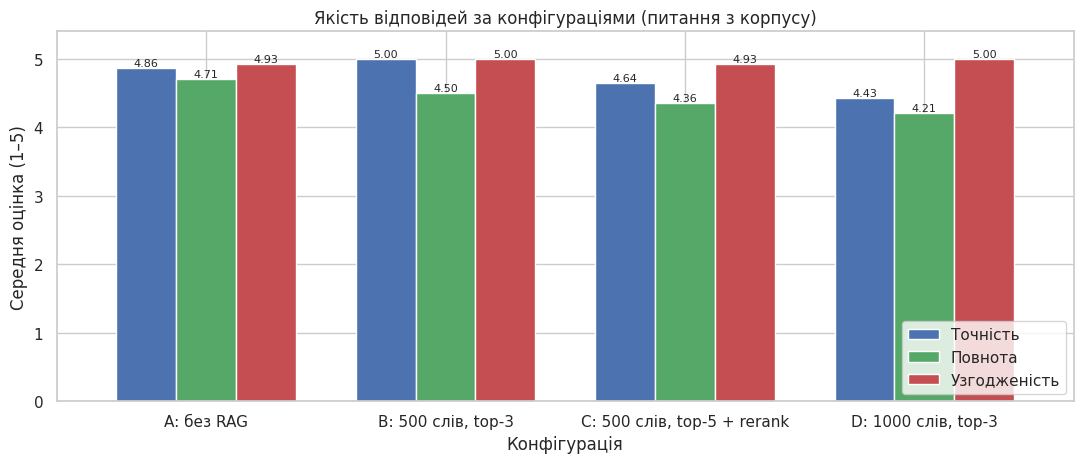

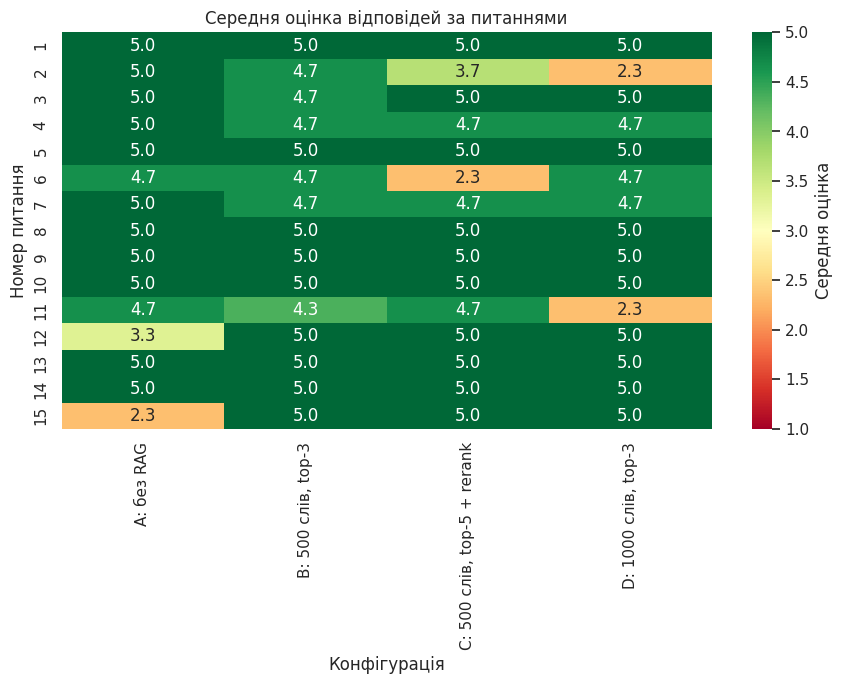

In [54]:
# Графік: середні оцінки точності, повноти й узгодженості для кожної конфігурації
ax = summary[["Точність", "Повнота", "Узгодженість"]].plot(kind="bar", figsize=(11, 4.8), width=0.75,
                                                             color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylim(0, 5.4)
ax.set_ylabel("Середня оцінка (1–5)")
ax.set_title("Якість відповідей за конфігураціями (питання з корпусу)")
ax.tick_params(axis="x", rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Теплова карта: середня оцінка для кожного питання і конфігурації
pivot = results_df.pivot(index="id", columns="Конфігурація", values="Середня оцінка")
plt.figure(figsize=(9, 7))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", vmin=1, vmax=5, cbar_kws={"label": "Середня оцінка"})
plt.title("Середня оцінка відповідей за питаннями")
plt.ylabel("Номер питання")
plt.tight_layout()
plt.show()

In [55]:
# Приклад: відповіді всіх конфігурацій на одне питання з коментарями судді
example_id = 1
print("Питання:", EVAL_SET[example_id - 1]["question"])
print("Еталон:", EVAL_SET[example_id - 1]["reference"], "\n")
for cfg_name in CONFIGS:
    key = f"{cfg_name}|{example_id}"
    s = scores[key]
    print(f"--- {cfg_name} | точність {s['accuracy']}, повнота {s['completeness']}, узгодженість {s['coherence']}")
    print(textwrap.fill(answers[key]["answer"], width=120, replace_whitespace=False))
    print("Коментар судді:", s["comment"], "\n")

Питання: За якої затримки рейсу і яку грошову компенсацію передбачає регламент ЄС № 261/2004?
Еталон: Компенсація належить за затримку понад три години. Сума залежить від відстані: 250 євро для рейсів до 1500 км, 400 євро для рейсів 1500–3500 км, 600 євро для рейсів понад 3500 км. 

--- A: без RAG | точність 5, повнота 5, узгодженість 5
Згідно з Регламентом ЄС № 261/2004, пасажири мають право на компенсацію у разі затримки рейсу в кінцевому пункті
призначення на **3 години і більше**. 

Розмір компенсації залежить від дальності польоту і становить:
* **250 євро** —
для рейсів на відстань до 1500 км;
* **400 євро** — для рейсів у межах ЄС понад 1500 км, а також для інших рейсів на
відстань від 1500 до 3500 км;
* **600 євро** — для рейсів на відстань понад 3500 км.

Компенсація не виплачується, якщо
затримка сталася через надзвичайні обставини (наприклад, погодні умови чи страйки), які авіакомпанія не могла
попередити.
Коментар судді: Відповідь системи повністю відповідає еталонній, є то

## 12. Інтерактивний чат

Простий чат-інтерфейс Gradio прямо в Colab: під кожною відповіддю показуються джерела та їхня косинусна подібність,
а історія діалогу зберігається між повідомленнями.

In [56]:
import gradio as gr

# Окремий чат з історією для інтерфейсу
ui_chat = RAGChat(store_500, top_k=4, use_reranker=True)


# Функція обробки повідомлення: відповідь RAG + список джерел
def respond(message, history):
    res = ui_chat.ask(message)
    sources = "\n".join(f"[{r['rank']}] {r['title']}, фрагмент {r['chunk_index'] + 1} (косинус {r['cosine']:.3f})"
                        for r in res["sources"])
    return f"{res['answer']}\n\nДжерела:\n{sources}"


# Запускаємо чат-інтерфейс
gr.ChatInterface(respond, title="RAG-асистент: авіаперевезення та задоволеність пасажирів").launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cd3b3ace8f9070f28c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
